# Day 12

We can see that our numpy code is working fast, but let's check is it even useful.

We will work with MNIST data

For multi class classification we uses softmax and not other function, there are 2 sides, \
you can learn about them in  \
1. https://www.pinecone.io/learn/softmax-activation/
2. https://stackoverflow.com/questions/17187507/why-use-softmax-as-opposed-to-standard-normalization
3. https://stats.stackexchange.com/questions/162988/why-sigmoid-function-instead-of-anything-else/318209#318209
4. refer notes

In [1]:
import numpy as np
import pandas as pd

In [49]:
# we will implement it 
def softmax(inputs):
    # print(inputs)
    exp_in = np.exp(inputs)
    # print(exp_in)
    summation = np.sum(exp_in)
    # print(summation)
    softmax_vals = np.round(exp_in/summation, 3)
    return softmax_vals

In [3]:
softmax([1.0, 2.3, 3.4])

array([0.064, 0.234, 0.702])

Cross entropy loss is used
1. https://www.pinecone.io/learn/cross-entropy-loss/
2. https://medium.com/@chris.p.hughes10/a-brief-overview-of-cross-entropy-loss-523aa56b75d5

In [6]:
# binary cross entropy
def binary_cross_entropy(t, p):
    return -np.sum(t * np.log(p) + (1-t) * np.log(1-p))

In [8]:
print(binary_cross_entropy(np.array([1.0, 0.0, 0.0]), np.array([0.28, 0.22, 0.50])))
print(binary_cross_entropy(np.array([1.0, 0.0, 0.0]), np.array([0.78, 0.12, 0.10])))

2.214574215671332
0.4816552464662108


In [9]:
def categorical_cross_entropy(t,p):
    return -np.sum(t * np.log(p))

In [10]:
t_list = [[1,0,0],[0,1,0],[0,0,1],[1,0,0]]
p_list = [[0.91,0.04,0.05],[0.11,0.8,0.09],[0.3,0.1,0.6],[0.25,0.4,0.35]]

In [12]:
print(categorical_cross_entropy(t_list, p_list))

2.214574215671332


### Now we will start with mnist data

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)

In [3]:
print(mnist.data.shape)
print(type(mnist.data))
print(mnist.target[:5])

(70000, 784)
<class 'pandas.DataFrame'>
0    5
1    0
2    4
3    1
4    9
Name: class, dtype: category
Categories (10, str): ['0', '1', '2', '3', ..., '6', '7', '8', '9']


In [4]:
inputs = mnist.data.to_numpy(dtype='float64')
print(inputs[0][100:200])
inputs/=256.0
print(inputs[0][100:200])

[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   3.  18.  18.  18.
 126. 136. 175.  26. 166. 255. 247. 127.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.  30.  36.  94. 154. 170. 253. 253. 253.
 253. 253. 225. 172. 253. 242. 195.  64.   0.   0.   0.   0.   0.   0.
   0.   0.]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.     

In [5]:
y_true = mnist.target.to_numpy()

In [6]:
y_true[:5]

array(['5', '0', '4', '1', '9'], dtype=object)

In [7]:
y_true = y_true.astype(int)

In [8]:
y_true[:5]

array([5, 0, 4, 1, 9])

In [9]:
num_classes = 10

In [10]:
y_true = np.eye(num_classes)[y_true]

In [11]:
y_true[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [12]:
def softmax(inputs):
    shifted = inputs - np.max(inputs)
    exp_in = np.exp(shifted)
    summation = np.sum(exp_in)
    return exp_in / summation

In [13]:
class MLP:
    def __init__(self, layer_list, activation_list=None):
        self.w = [rg.uniform(-1,1,(layer_list[i], layer_list[i-1]))for i in range(1,len(layer_list))]
        self.w_grad = [np.zeros((layer_list[i], layer_list[i-1])) for i in range(1,len(layer_list))]
        self.b = [np.zeros(layer_list[i]).reshape(-1,1) for i in range(1,len(layer_list))]
        self.b_grad = [np.zeros(layer_list[i]).reshape(-1,1) for i in range(1,len(layer_list))]
        self.activation_list = activation_list
        self.Q = [np.zeros(layer_list[i]).reshape(1,-1) for i in range(0,len(layer_list))]
        self.output_values = None
        self.layer_list = layer_list
        
    def forward(self, inputs):
        # Reset if already has some value
        for i in range(len(self.layer_list)-1):
            self.Q[i][:] = 0
        # layer output will have output length as no. of neurons i.e. self.neurons
        self.output_values = [None] * len(self.layer_list)
        self.output_values[0] = np.array(inputs).reshape(-1,1)
        for k in range(1,len(self.layer_list)):
            self.Q[k] = self.w[k-1] @ self.output_values[k-1] + self.b[k-1]
            if self.activation_list[k-1] == 'tanh':
                self.output_values[k] = np.tanh(self.Q[k])
            elif self.activation_list[k-1] == 'ReLU':
                self.output_values[k] = np.clip(self.Q[k],a_min=0,a_max=None)
            elif self.activation_list[k-1] == 'softmax':
                self.output_values[k] =  self.Q[k]
        
        return self.output_values[-1]
        
    def backward(self, loss_grad): 
        grad_in = loss_grad
        for l in range(len(self.layer_list)-1,0,-1):
            dfdq = np.ones_like(grad_in)
            if self.activation_list[l-1] == 'tanh':
                dfdq = (1-((self.output_values[l])**2))
                dLdQ = grad_in * dfdq
            elif self.activation_list[l-1] == 'ReLU':
                dfdq = (self.Q[l] > 0).astype(float)
                dLdQ = grad_in * dfdq
            elif self.activation_list[l-1] == 'softmax':
                dLdQ = grad_in
            self.b_grad[l-1] += dLdQ
            self.w_grad[l-1] += dLdQ @ self.output_values[l-1].T
            grad_in =  self.w[l-1].T @ dLdQ
            
            
    def parameters(self):
        return (self.w, self.b)
        
    def grads(self):
        return (self.w_grad, self.b_grad)

In [14]:
def cross_entropy_loss(t, z):
    p = softmax(z)
    ind = np.argmax(t)
    # print(ind)
    # print(t)
    # print(p)
    loss = -1 * np.log(p[ind])
    grad = p - t
    return (loss, grad)

In [15]:

nn = MLP([784, 32, 10], [ 'ReLU', 'softmax'])

In [16]:
class SGD:
    def __init__(self, weights, bias, weights_grad, bias_grad, learning_rate=0.01):
        self.weights = weights
        self.bias = bias
        self.weights_grad = weights_grad
        self.bias_grad = bias_grad
        self.learning_rate = learning_rate

    def step(self):
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * self.weights_grad[i]
            self.bias[i] -= self.learning_rate * self.bias_grad[i]
                    
        
    def zero_grad(self):
        for i in range(len(self.weights_grad)):
            self.weights_grad[i][:] = 0
            self.bias_grad[i][:] = 0

In [17]:
# training loop
epochs = 10
train_size = 100

In [18]:
optimizer = SGD(nn.parameters()[0],nn.parameters()[1] , nn.grads()[0], nn.grads()[1], 0.10)

In [19]:
epoch_values = []
loss_values = []
for epoch in range(epochs):
    # forward pass
    # find loss, grad
    total_loss = 0.0
    for i in range(train_size):
        output = nn.forward(inputs[i])
        loss, grad = cross_entropy_loss(y_true[i].reshape(-1,1), output)
        total_loss += loss
        nn.backward(grad)
    # step
    optimizer.step()
    optimizer.zero_grad()
    epoch_values.append(epoch)
    loss_values.append(total_loss)
    print(f"epoch {epoch}, total loss: {total_loss}")
output = nn.forward(inputs[-1])
print(softmax(output))
print(np.argmax(output))



epoch 0, total loss: [1781.51441456]
epoch 1, total loss: [inf]
epoch 2, total loss: [inf]
epoch 3, total loss: [inf]
epoch 4, total loss: [inf]
epoch 5, total loss: [574.47085034]
epoch 6, total loss: [462.47155642]
epoch 7, total loss: [360.32018233]
epoch 8, total loss: [311.52248297]
epoch 9, total loss: [277.58643862]
[[0.07404365]
 [0.15230339]
 [0.08227222]
 [0.13228756]
 [0.12975298]
 [0.07303638]
 [0.00620306]
 [0.1193885 ]
 [0.10113611]
 [0.12957615]]
1


/var/folders/mg/1n00pzb54c170d0lsydjt6380000gn/T/ipykernel_67235/403837349.py:7: RuntimeWarning: divide by zero encountered in log
  loss = -1 * np.log(p[ind])


In [20]:
print(inputs[-1])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.03125    0.45703125 0.9921875  0.859375   0.34765625
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.05078125 0.3

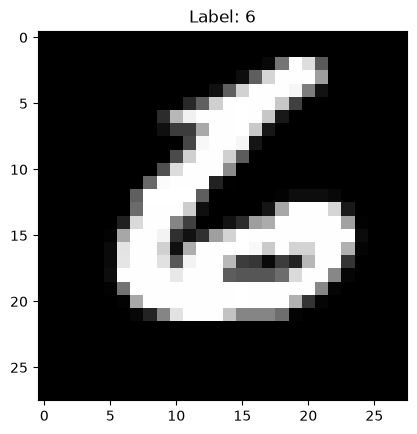

In [21]:
import matplotlib.pyplot as plt

plt.imshow(inputs[-1].reshape(28, 28), cmap='gray')
plt.title(f"Label: {np.argmax(y_true[-1])}")
plt.show()

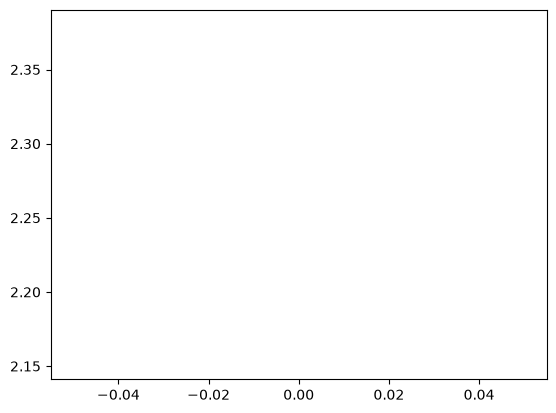

In [68]:
import matplotlib.pyplot as plt
plt.plot(epoch_values,loss_values)

# Day 13

### Full from top to bottom

In [6]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
rg = np.random.default_rng()

In [7]:
def softmax(inputs):
    shifted = inputs - np.max(inputs)
    exp_in = np.exp(shifted)
    summation = np.sum(exp_in)
    return exp_in / summation

In [8]:
def cross_entropy_loss(t, z):
    p = softmax(z)
    ind = np.argmax(t)
    loss = -1 * np.log(p[ind])
    grad = p - t
    return (loss, grad)

In [9]:
class MLP:
    def __init__(self, layer_list, activation_list=None):
        self.w = [(rg.uniform(-1,1,(layer_list[i], layer_list[i-1]))/np.sqrt(layer_list[i-1]))for i in range(1,len(layer_list))]
        self.w_grad = [np.zeros((layer_list[i], layer_list[i-1])) for i in range(1,len(layer_list))]
        self.b = [np.zeros(layer_list[i]).reshape(-1,1) for i in range(1,len(layer_list))]
        self.b_grad = [np.zeros(layer_list[i]).reshape(-1,1) for i in range(1,len(layer_list))]
        self.activation_list = activation_list
        self.Q = [np.zeros(layer_list[i]).reshape(1,-1) for i in range(0,len(layer_list))]
        self.output_values = None
        self.layer_list = layer_list
        
    def forward(self, inputs):
        # Reset if already has some value
        for i in range(len(self.layer_list)-1):
            self.Q[i][:] = 0
        # layer output will have output length as no. of neurons i.e. self.neurons
        self.output_values = [None] * len(self.layer_list)
        self.output_values[0] = np.array(inputs).reshape(-1,1)
        for k in range(1,len(self.layer_list)):
            self.Q[k] = self.w[k-1] @ self.output_values[k-1] + self.b[k-1]
            if self.activation_list[k-1] == 'tanh':
                self.output_values[k] = np.tanh(self.Q[k])
            elif self.activation_list[k-1] == 'ReLU':
                self.output_values[k] = np.clip(self.Q[k],a_min=0,a_max=None)
            elif self.activation_list[k-1] == 'softmax':
                self.output_values[k] =  self.Q[k]
        
        return self.output_values[-1]
        
    def backward(self, loss_grad): 
        grad_in = loss_grad
        for l in range(len(self.layer_list)-1,0,-1):
            dfdq = np.ones_like(grad_in)
            if self.activation_list[l-1] == 'tanh':
                dfdq = (1-((self.output_values[l])**2))
                dLdQ = grad_in * dfdq
            elif self.activation_list[l-1] == 'ReLU':
                dfdq = (self.Q[l] > 0).astype(float)
                dLdQ = grad_in * dfdq
            elif self.activation_list[l-1] == 'softmax':
                dLdQ = grad_in
            self.b_grad[l-1] += dLdQ
            self.w_grad[l-1] += dLdQ @ self.output_values[l-1].T
            grad_in =  self.w[l-1].T @ dLdQ
            
            
    def parameters(self):
        return (self.w, self.b)
        
    def grads(self):
        return (self.w_grad, self.b_grad)

In [10]:
class SGD:
    def __init__(self, weights, bias, weights_grad, bias_grad, learning_rate=0.01):
        self.weights = weights
        self.bias = bias
        self.weights_grad = weights_grad
        self.bias_grad = bias_grad
        self.learning_rate = learning_rate

    def step(self):
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * self.weights_grad[i]
            self.bias[i] -= self.learning_rate * self.bias_grad[i]
                    
        
    def zero_grad(self):
        for i in range(len(self.weights_grad)):
            self.weights_grad[i][:] = 0
            self.bias_grad[i][:] = 0

In [11]:
mnist = fetch_openml('mnist_784', version=1)

In [12]:
inputs = mnist.data.to_numpy(dtype='float64')
print(inputs[0][100:200])
inputs/=256.0
print(inputs[0][100:200])

[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   3.  18.  18.  18.
 126. 136. 175.  26. 166. 255. 247. 127.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.  30.  36.  94. 154. 170. 253. 253. 253.
 253. 253. 225. 172. 253. 242. 195.  64.   0.   0.   0.   0.   0.   0.
   0.   0.]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.     

In [13]:
y_true = mnist.target.to_numpy()
y_true = y_true.astype(int)
num_classes = 10
y_true = np.eye(num_classes)[y_true]

In [14]:
y_true[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [137]:
# training loop
epochs = 500
train_size = 5000
batch_size = 32
start = 0

In [138]:
nn = MLP([784, 128, 10], [ 'ReLU', 'softmax'])

In [144]:
optimizer = SGD(nn.parameters()[0],nn.parameters()[1] , nn.grads()[0], nn.grads()[1], 0.05)

In [148]:
epoch_values = []
loss_values = []
for epoch in range(epochs):
    # forward pass
    # find loss, grad
    total_loss = 0.0
    for i in range(start, start+batch_size):
        output = nn.forward(inputs[i])
        loss, grad = cross_entropy_loss(y_true[i].reshape(-1,1), output)
        total_loss += loss
        nn.backward(grad)
    # step
    optimizer.step()
    optimizer.zero_grad()
    epoch_values.append(epoch)
    loss_values.append(total_loss)
    print(f"epoch {epoch}, total loss: {total_loss}")
    start+=batch_size
output = nn.forward(inputs[-1])
print(softmax(output))
print(np.argmax(output))



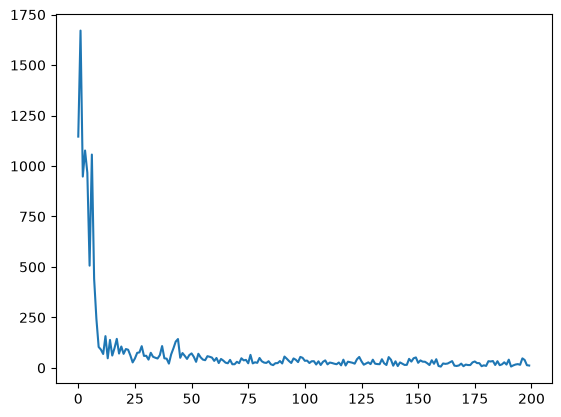

In [133]:
plt.plot(epoch_values,loss_values)

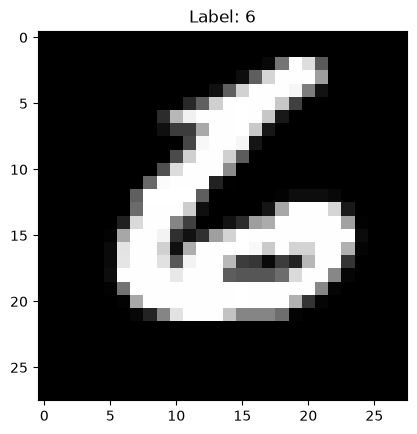

In [120]:
import matplotlib.pyplot as plt

plt.imshow(inputs[-1].reshape(28, 28), cmap='gray')
plt.title(f"Label: {np.argmax(y_true[-1])}")
plt.show()

In [146]:
y_pred = [-1] * 100

for i in range(-100,0,1):
    output = nn.forward(inputs[i])
    y_pred[i] = (np.argmax(output))
    # print(np.argmax(output))
    # plt.imshow(inputs[i].reshape(28, 28), cmap='gray')
    # plt.title(f"Label: {np.argmax(y_true[i])}")
    # plt.show()

In [147]:
correct = 0
for y_true_i, y_pred_i in zip(y_true[-100:], y_pred):
    correct += 1 if np.argmax(y_true_i) == y_pred_i else 0

print(correct)
    

80


In [111]:
y_true[-10:]

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]])

### Experiments

In [154]:
nn_test = MLP([784, 128, 10], [ 'ReLU', 'softmax'])

In [15]:
def train_model(model, epochs=500, batch_size=32, lr=0.05):
    optimizer = SGD(model.parameters()[0], model.parameters()[1] ,model.grads()[0], model.grads()[1], lr)
    epoch_values = []
    loss_values = []
    start = 0
    for epoch in range(epochs):
        # forward pass
        # find loss, grad
        total_loss = 0.0
        for i in range(start, start+batch_size):
            output = model.forward(inputs[i])
            loss, grad = cross_entropy_loss(y_true[i].reshape(-1,1), output)
            total_loss += loss
            model.backward(grad)
        # step
        optimizer.step()
        optimizer.zero_grad()
        epoch_values.append(epoch)
        loss_values.append(total_loss)
        # if epoch%100 == 0:
        #     print(f"epoch {epoch}, total loss: {total_loss}")
        start+=batch_size
    # output = nn.forward(inputs[-1])
    # print(softmax(output))
    # print(np.argmax(output))



In [16]:
def accuracy(model, test_input, true_outputs):
    y_pred = [-1] * 100
    for i in range(-100,0,1):
        output = model.forward(test_input[i])
        y_pred[i] = (np.argmax(output))
    correct = 0
    for y_true_i, y_pred_i in zip(true_outputs[-100:], y_pred):
        correct += 1 if np.argmax(y_true_i) == y_pred_i else 0
    return correct

In [17]:
nn1 = MLP([784, 128, 10], [ 'ReLU', 'softmax'])
nn2 = MLP([784, 64, 10], [ 'ReLU', 'softmax'])
nn3 = MLP([784, 32, 10], [ 'ReLU', 'softmax'])
nn4 = MLP([784, 128, 32, 10], [ 'ReLU', 'ReLU', 'softmax'])
nn5 = MLP([784, 128, 64, 10], [ 'ReLU', 'ReLU','softmax'])
nn6 = MLP([784, 64, 32, 10], [ 'ReLU', 'ReLU','softmax'])
nn7 = MLP([784, 32, 64, 10], [ 'ReLU', 'ReLU','softmax'])
nn8 = MLP([784, 32, 128, 10], [ 'ReLU', 'ReLU','softmax'])
nn9 = MLP([784, 64, 128, 10], [ 'ReLU', 'ReLU','softmax'])
nn10 = MLP([784, 32, 64, 128, 10], [ 'ReLU', 'ReLU','ReLU','softmax'])
nn11 = MLP([784, 128, 64, 32, 10], [ 'ReLU', 'ReLU','ReLU','softmax'])
models = [nn1,nn2,nn3,nn4,nn5,nn6,nn7,nn8,nn9,nn10,nn11]

In [18]:
train_model(nn_test, epochs=epochs, lr=0.05)

NameError: name 'nn_test' is not defined

In [181]:
correct_nn_test = accuracy(nn_test, inputs[-100:], y_true[-100:])
print(correct_nn_test)

83


In [21]:
for i in range(11):
    train_model(model=models[i], epochs=500, batch_size=32, lr=0.01)
    correct_nn_test = accuracy(models[i], inputs[-100:], y_true[-100:])
    print(f"model {i+1} accuracy: {correct_nn_test}")

model 1 accuracy: 93
model 2 accuracy: 92
model 3 accuracy: 90
model 4 accuracy: 91
model 5 accuracy: 92
model 6 accuracy: 88
model 7 accuracy: 86
model 8 accuracy: 84
model 9 accuracy: 95
model 10 accuracy: 81
model 11 accuracy: 85


In [187]:
nn11 = MLP([784, 128, 64, 32, 10], [ 'ReLU', 'ReLU','ReLU','softmax'])
train_model(nn11, epochs, batch_size, 0.01)
correct_nn_test = accuracy(nn11, inputs[-100:], y_true[-100:])

epoch 0, total loss: [73.65873314]
epoch 100, total loss: [33.94152285]
epoch 200, total loss: [15.17611233]
epoch 300, total loss: [8.43140317]
epoch 400, total loss: [5.17383384]
[[6.19313242e-09]
 [4.12302869e-09]
 [8.39629861e-12]
 [4.99991040e-09]
 [1.14489947e-04]
 [6.16636721e-04]
 [9.99268854e-01]
 [7.82326724e-11]
 [4.29324470e-09]
 [4.72135077e-11]]
6


In [190]:
nn11 = MLP([784, 128, 10], [ 'ReLU', 'ReLU','ReLU','softmax'])
train_model(nn11, epochs, batch_size, 0.01)
correct_nn_test = accuracy(nn11, inputs[-100:], y_true[-100:])

[[6.19313242e-09]
 [4.12302869e-09]
 [8.39629861e-12]
 [4.99991040e-09]
 [1.14489947e-04]
 [6.16636721e-04]
 [9.99268854e-01]
 [7.82326724e-11]
 [4.29324470e-09]
 [4.72135077e-11]]
6


In [191]:
print(correct_nn_test)

87


1


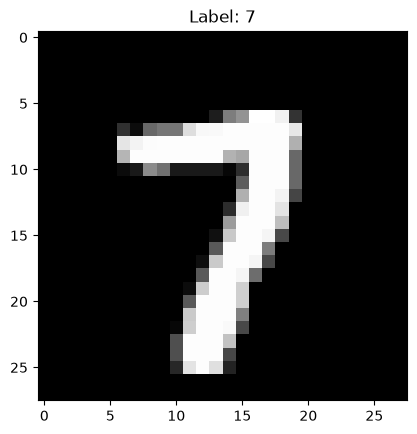

1


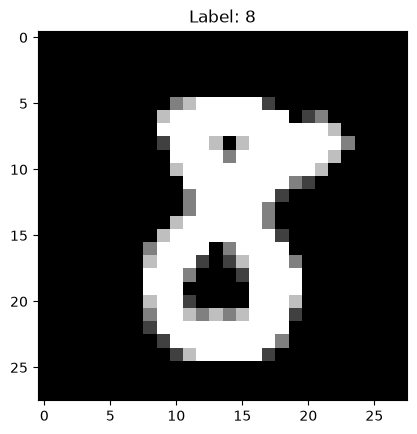

1


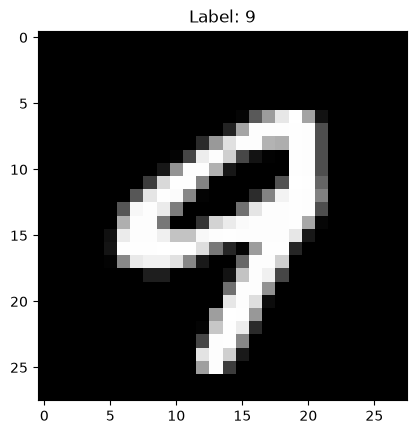

1


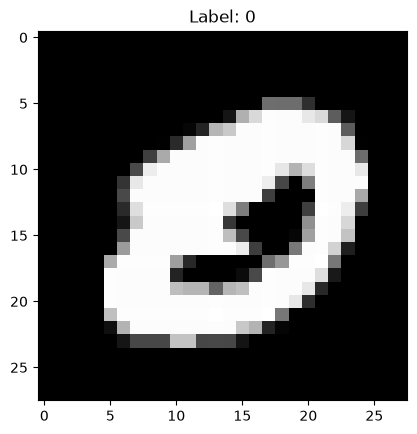

1


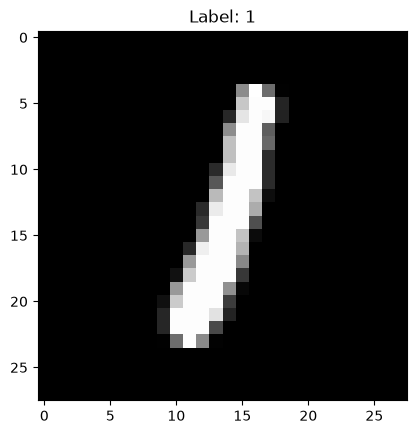

1


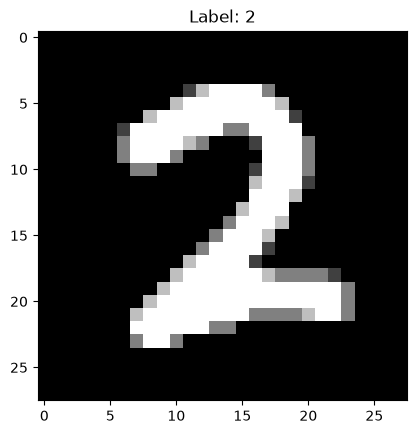

1


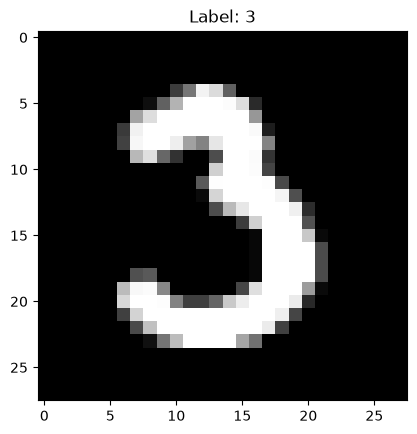

1


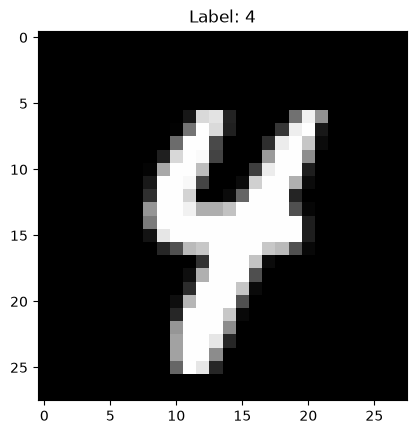

1


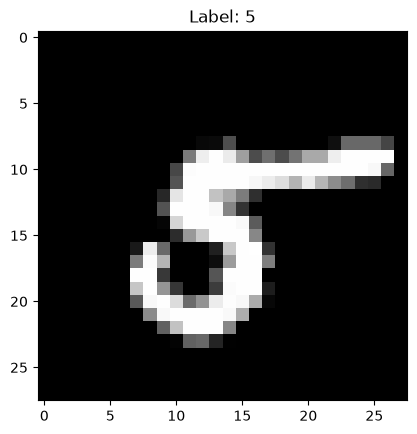

1


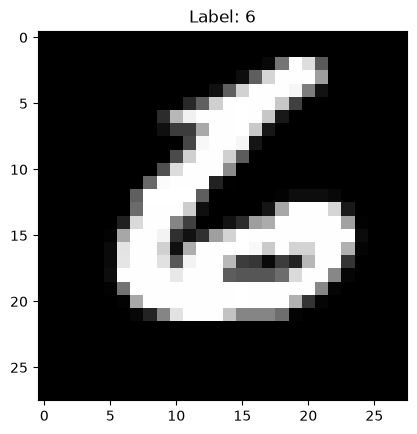

In [176]:
for i in range(-10,0,1):
    output = nn11.forward(inputs[i])
    # y_pred[i] = (np.argmax(output))
    print(np.argmax(output))
    plt.imshow(inputs[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_true[i])}")
    plt.show()

epoch 0, total loss: [73.66715083]
accuracy: 17
epoch 100, total loss: [65.88579447]
accuracy: 42
epoch 200, total loss: [23.73873825]
accuracy: 61
epoch 300, total loss: [21.54727382]
accuracy: 73
epoch 400, total loss: [13.89755902]
accuracy: 82
epoch 500, total loss: [17.35756681]
accuracy: 84
epoch 600, total loss: [9.66043108]
accuracy: 86
epoch 700, total loss: [6.40828526]
accuracy: 85
epoch 800, total loss: [6.71147379]
accuracy: 86
epoch 900, total loss: [5.13119651]
accuracy: 85
epoch 1000, total loss: [15.08837092]
accuracy: 91
epoch 1100, total loss: [6.27831304]
accuracy: 92
epoch 1200, total loss: [5.98384737]
accuracy: 87
epoch 1300, total loss: [9.1562717]
accuracy: 90
epoch 1400, total loss: [8.31094572]
accuracy: 90
epoch 1500, total loss: [10.82244159]
accuracy: 93
epoch 1600, total loss: [4.83963525]
accuracy: 94
epoch 1700, total loss: [10.36663303]
accuracy: 92
epoch 1800, total loss: [7.89005272]
accuracy: 95
epoch 1900, total loss: [4.75735194]
accuracy: 91
accu

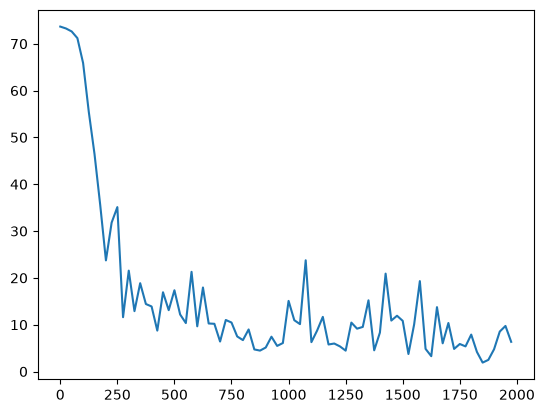

In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
rg = np.random.default_rng()
import matplotlib.pyplot as plt
import time
start_time = time.time()

def softmax(inputs):
    shifted = inputs - np.max(inputs)
    exp_in = np.exp(shifted)
    summation = np.sum(exp_in)
    return exp_in / summation

def cross_entropy_loss(t, z):
    p = softmax(z)
    ind = np.argmax(t)
    loss = -1 * np.log(p[ind])
    grad = p - t
    return (loss, grad)

class MLP:
    def __init__(self, layer_list, activation_list=None):
        self.w = [(rg.uniform(-1,1,(layer_list[i], layer_list[i-1]))/np.sqrt(layer_list[i-1]))for i in range(1,len(layer_list))]
        self.w_grad = [np.zeros((layer_list[i], layer_list[i-1])) for i in range(1,len(layer_list))]
        self.b = [np.zeros(layer_list[i]).reshape(-1,1) for i in range(1,len(layer_list))]
        self.b_grad = [np.zeros(layer_list[i]).reshape(-1,1) for i in range(1,len(layer_list))]
        self.activation_list = activation_list
        self.Q = [np.zeros(layer_list[i]).reshape(1,-1) for i in range(0,len(layer_list))]
        self.output_values = None
        self.layer_list = layer_list
        
    def forward(self, inputs):
        # Reset if already has some value
        for i in range(len(self.layer_list)-1):
            self.Q[i][:] = 0
        # layer output will have output length as no. of neurons i.e. self.neurons
        self.output_values = [None] * len(self.layer_list)
        self.output_values[0] = np.array(inputs).reshape(-1,1)
        for k in range(1,len(self.layer_list)):
            self.Q[k] = self.w[k-1] @ self.output_values[k-1] + self.b[k-1]
            if self.activation_list[k-1] == 'tanh':
                self.output_values[k] = np.tanh(self.Q[k])
            elif self.activation_list[k-1] == 'ReLU':
                self.output_values[k] = np.clip(self.Q[k],a_min=0,a_max=None)
            elif self.activation_list[k-1] == 'softmax':
                self.output_values[k] =  self.Q[k]
        
        return self.output_values[-1]
        
    def backward(self, loss_grad): 
        grad_in = loss_grad
        for l in range(len(self.layer_list)-1,0,-1):
            dfdq = np.ones_like(grad_in)
            if self.activation_list[l-1] == 'tanh':
                dfdq = (1-((self.output_values[l])**2))
                dLdQ = grad_in * dfdq
            elif self.activation_list[l-1] == 'ReLU':
                dfdq = (self.Q[l] > 0).astype(float)
                dLdQ = grad_in * dfdq
            elif self.activation_list[l-1] == 'softmax':
                dLdQ = grad_in
            self.b_grad[l-1] += dLdQ
            self.w_grad[l-1] += dLdQ @ self.output_values[l-1].T
            grad_in =  self.w[l-1].T @ dLdQ
            
            
    def parameters(self):
        return (self.w, self.b)
        
    def grads(self):
        return (self.w_grad, self.b_grad)

class SGD:
    def __init__(self, weights, bias, weights_grad, bias_grad, learning_rate=0.01):
        self.weights = weights
        self.bias = bias
        self.weights_grad = weights_grad
        self.bias_grad = bias_grad
        self.learning_rate = learning_rate

    def step(self):
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * self.weights_grad[i]
            self.bias[i] -= self.learning_rate * self.bias_grad[i]
                    
        
    def zero_grad(self):
        for i in range(len(self.weights_grad)):
            self.weights_grad[i][:] = 0
            self.bias_grad[i][:] = 0

def accuracy(model, test_input, true_outputs):
    y_pred = [-1] * 100
    for i in range(-100,0,1):
        output = model.forward(test_input[i])
        y_pred[i] = (np.argmax(output))
    correct = 0
    for y_true_i, y_pred_i in zip(true_outputs[-100:], y_pred):
        correct += 1 if np.argmax(y_true_i) == y_pred_i else 0
    return correct

mnist = fetch_openml('mnist_784', version=1)
inputs = mnist.data.to_numpy(dtype='float64')
# print(inputs[0][100:200])
inputs/=256.0
# print(inputs[0][100:200])
y_true = mnist.target.to_numpy()
y_true = y_true.astype(int)
num_classes = 10
y_true = np.eye(num_classes)[y_true]
epochs = 2000
train_size = 70000
batch_size = 32
nn = MLP([784, 128, 64, 32, 10], [ 'ReLU','ReLU', 'ReLU','softmax'])
optimizer = SGD(nn.parameters()[0],nn.parameters()[1] , nn.grads()[0], nn.grads()[1], 0.0025)
start = 0
epoch_values = []
loss_values = []
for epoch in range(epochs):
    # forward pass
    # find loss, grad
    total_loss = 0.0
    for i in range(start, start+batch_size):
        output = nn.forward(inputs[i])
        loss, grad = cross_entropy_loss(y_true[i].reshape(-1,1), output)
        total_loss += loss
        nn.backward(grad)
    # step
    optimizer.step()
    optimizer.zero_grad()
    if epoch%25 == 0:
        epoch_values.append(epoch)
        loss_values.append(total_loss)
    if epoch%100 == 0:
        print(f"epoch {epoch}, total loss: {total_loss}")  
        print(f"accuracy: {accuracy(nn, inputs, y_true)}")
        
    start+=batch_size
    start%=(train_size-batch_size)
    
def accuracy(model, test_input, true_outputs):
    y_pred = [-1] * 100
    for i in range(-100,0,1):
        output = model.forward(test_input[i])
        y_pred[i] = (np.argmax(output))
    correct = 0
    for y_true_i, y_pred_i in zip(true_outputs[-100:], y_pred):
        correct += 1 if np.argmax(y_true_i) == y_pred_i else 0
    return correct
print(f"accuracy: {accuracy(nn, inputs[-100:], y_true[-100:])}")
plt.plot(epoch_values,loss_values)
end = time.time()
print(f"Time taken: {end - start_time} seconds")

we are training our model in around 13 seconds, is it fast or slow, how to know, can we use this on large scale, how to compare, with what to compare, for all this I am staritng with a new chapter, it is mostly theory, so notes, lectires , articles, books will be provided and what I understood.
    